Code timing and profiling for optimization

In [1]:
# %pip install line_profiler
%load_ext line_profiler


In [2]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib.pyplot as plt

from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [3]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 10000.0 # Depth

In [4]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 100
R_max = 1000
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = x_scale * np.random.rand(N_chamber)
y_nodes = y_scale * np.random.rand(N_chamber)
z_nodes = z_scale * np.random.rand(N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

list_nodes


[Chamber at      (5488.1350392732475, 0.0, 9786.18342232764)
 Mass (kg)       2.13880e+12
 Energy (MJ)     2.61621e+12
 Volume (m^3)    1111248578.8533103
 Temperature (K) 1200.0000000
 Pressure (MPa)  -273.91313583
 Density (kg)    1924.686056
 Depth (km)      9.786183,
 Chamber at      (7151.893663724195, 0.0, 7991.585642167236)
 Mass (kg)       6.49504e+12
 Energy (MJ)     7.89434e+12
 Volume (m^3)    3244048182.2279434
 Temperature (K) 1200.0000000
 Pressure (MPa)  -223.66439798
 Density (kg)    2002.139249
 Depth (km)      7.991586,
 Chamber at      (6027.633760716439, 0.0, 4614.793622529319)
 Mass (kg)       4.14386e+12
 Energy (MJ)     4.99535e+12
 Volume (m^3)    1912996115.6600239
 Temperature (K) 1200.0000000
 Pressure (MPa)  -129.11422143
 Density (kg)    2166.163412
 Depth (km)      4.614794,
 Chamber at      (5448.831829968969, 0.0, 7805.291762864555)
 Mass (kg)       4.79083e+12
 Energy (MJ)     5.81961e+12
 Volume (m^3)    2382858296.7367401
 Temperature (K) 1200.0000000

In [5]:
def task(N_t:int=100):

  ''' Set up for timestepping '''

  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=1e3,
                                    dpdx_threshold_scale=1e1,
                                    R_outer_ratio=20,)

  node = global_sys.nodes[0]
  q0 = global_sys.q0
  # Add mass increment in chamber N-1
  q0[global_sys.data_slice_global(global_sys.num_blocks - 1, "mass")] +=  mass_inj

  # Compute L, M(q), f
  L, M, f = global_sys.assemble_global_LMf(q0)

  # Time vector
  t_vec = None
  if t_vec is None:
    t1 = 1e9
    t2 = 0.5e12
    # Define vector of t points for both timescales
    t_vec = np.array([*np.linspace(0, t1, N_t+1), *np.linspace(t1, t2, N_t+1)[1:]])

  ''' Timestepping '''

  # Start q with initial condition
  q = q0.copy()
  # Allocate full output storage
  q_out = np.zeros((t_vec.size, *q.shape))
  # Save last dt for cache check
  dt = np.nan
  dt_last = np.nan
  dt_last_last = np.nan
  # Max order possible
  max_order = np.ones(t_vec.size, dtype=int)

  global_sys._step_strategy = np.zeros(t_vec.size, dtype=float)
  L, M, f = global_sys.assemble_global_LMf(q)
  # lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)

  for i, t in enumerate(t_vec):
    if i > 0:
      # Compute timestep
      dt = t_vec[i] - t_vec[i-1]

      M = global_sys.assemble_global_LMf(q, skip_Lf=True)

      # Strang split      
      # q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * L, q + f * dt)

      # Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
      q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * f)[:,np.newaxis]

      if False:
        # (1/3) BDF1, update matrix inv(I + dt*L)
        # lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)
        q = lu_out.solve(q + f * 0.5 * dt)
        # (2/3) Semi-BDF1, update matrix (approximate threshold explicitly, not implicitly)
        q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * M, q)[:,np.newaxis]
        # (3/3) BDF1, update matrix inv(I + dt*L)
        q = lu_out.solve(q + f * 0.5 * dt)
        global_sys._step_strategy[i] = 1.0

      if False:
        if method == 2 and np.isclose(dt, dt_last) and not np.isclose(dt_last_last, dt_last):
          # BDF2, update matrix
          lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + (2.0/3.0) * dt * L)
          q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
          global_sys._step_strategy[i] = 2.0
        elif method == 2 and np.isclose(dt, dt_last) and np.isclose(dt_last_last, dt_last):
          # BDF2, use cached matrix
          q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
          global_sys._step_strategy[i] = 2.5
        elif not np.isclose(dt, dt_last):
          # BDF1, update matrix inv(I + dt*L)
          lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + dt * L)
          q = lu_out.solve(q + f * dt)
          global_sys._step_strategy[i] = 1.0
        else:
          # BDF1, use cached matrix inv(I + dt*L)
          q = lu_out.solve(q + f * dt)
          global_sys._step_strategy[i] = 1.5

    dt_last_last = dt_last
    dt_last = dt
    q = np.reshape(q, (q.size, 1))
    # Save result
    q_out[i,...] = q


In [27]:
# %lprun -f task task()

In [8]:
N_t = 7

''' Set up for timestepping '''

global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                  r_hydr=r_hydr, mu0=mu0, 
                                  rho0=2500, K_f=K_f, Nr=50,
                                  dpdx_crit=1e1,
                                  dpdx_threshold_scale=1e0,
                                  R_outer_ratio=20,)

node = global_sys.nodes[0]
q0 = global_sys.q0
# Add mass increment in chamber N-1
q0[global_sys.data_slice_global(global_sys.num_blocks - 1, "mass")] +=  mass_inj

# Compute L, M(q), f
L, M, f = global_sys.assemble_global_LMf(q0)

# Time vector
t_vec = None
if t_vec is None:
  t1 = 1e9
  t2 = 0.5e12 # LONG TIMESCALE
  # t2 = 1.2e9   # OVERRIDE
  # Define vector of t points for both timescales
  t_vec = np.array([*np.linspace(0, t1, N_t+1), *np.linspace(t1, t2, N_t+1)[1:]])

''' Timestepping '''

# Start q with initial condition
q = q0.copy()
# Allocate full output storage
q_out = np.zeros((t_vec.size, *q.shape))
# Save last dt for cache check
dt = np.nan
dt_last = np.nan
dt_last_last = np.nan
# Max order possible
max_order = np.ones(t_vec.size, dtype=int)

global_sys._step_strategy = np.zeros(t_vec.size, dtype=float)
L, M, f = global_sys.assemble_global_LMf(q)
# lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)
print(M.nnz)

for i, t in enumerate(t_vec):
  if i > 0:
    # Compute timestep
    dt = t_vec[i] - t_vec[i-1]

    M = global_sys.assemble_global_LMf(q, skip_Lf=True)

    # Strang split      
    # q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * L, q + f * dt)

    # Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
    q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * f)[:,np.newaxis]
    if M.nnz > 0:
      print(M.nnz)
  if i == 2:
    break

2828
2828
9696


In [20]:
M

<1040x1040 sparse matrix of type '<class 'numpy.float64'>'
	with 9696 stored elements in Compressed Sparse Row format>

9

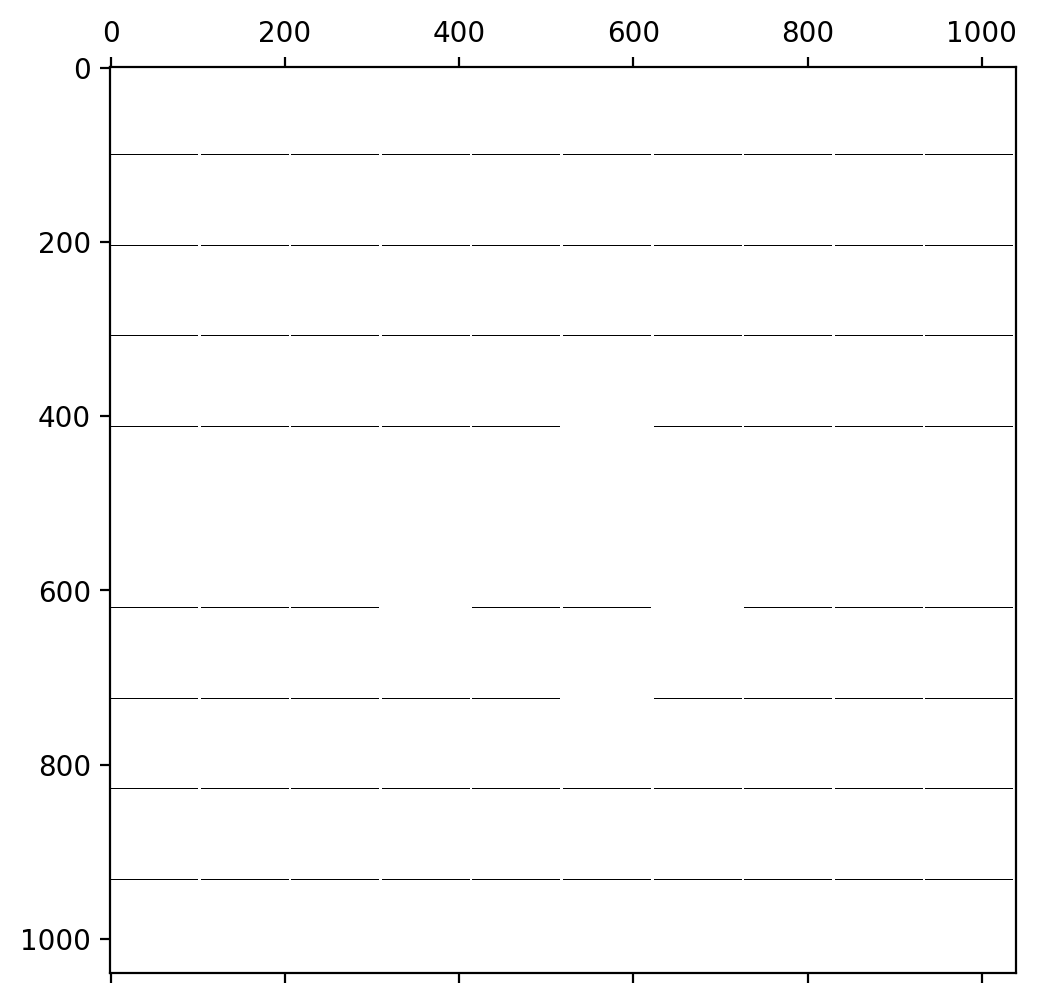

In [23]:
plt.figure(figsize=(6,6), dpi=200)
plt.spy(M.todense(), 0)
np.linalg.matrix_rank(M.todense())

In [24]:
print("Chamber pressures: ")
print(global_sys.pressure(q))

Chamber pressures: 
[[ 26403115.31003251]
 [ 36697178.60829218]
 [ 28467015.27361315]
 [ 37733850.82560392]
 [ 30114773.88377187]
 [ 37488142.80281083]
 [ 31590047.24283082]
 [-21193292.25086977]
 [ 24264211.89862892]
 [ 28124145.92480817]]


In [26]:
q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * f)[:,np.newaxis]

In [16]:
A = scipy.sparse.eye(global_sys.num_dof) + dt * (L + M)

In [17]:
M

<1040x1040 sparse matrix of type '<class 'numpy.float64'>'
	with 9696 stored elements in Compressed Sparse Row format>

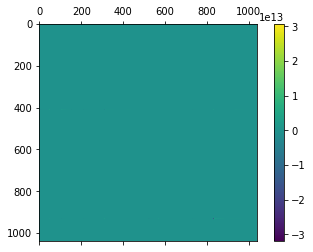

In [18]:
plt.matshow(A.todense(), 0)
plt.colorbar()